<a href="https://www.kaggle.com/code/sonawanelalitsunil/lung-cancer-risk-dataset-ml-74-40?scriptVersionId=260783077" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/lung-cancer-risk-dataset/lung_cancer_dataset.csv


## Title: Lung Cancer Risk Dataset

## Description:
This dataset contains demographic, lifestyle, and medical attributes related to lung cancer risk. It includes factors such as age, gender, smoking habits, family history, exposure to carcinogens, and other health indicators. The dataset can be used to analyze correlations, identify high-risk groups, and build predictive models for early detection and prevention of lung cancer.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/lung-cancer-risk-dataset/lung_cancer_dataset.csv")

In [3]:
df.head()

,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
0,100000,69,Male,66.025244,High,No,No,Yes,Moderate,No,No
1,100001,32,Female,12.780800,High,No,Yes,Yes,Moderate,Yes,Yes
2,100002,89,Female,0.408278,Medium,Yes,Yes,Yes,NaN,No,Yes
3,100003,78,Female,44.065232,Low,No,Yes,No,Moderate,No,Yes
4,100004,38,Female,44.432440,Medium,Yes,No,Yes,NaN,Yes,Yes


In [4]:
df.tail()

,patient_id,age,gender,pack_years,radon_exposure,asbestos_exposure,secondhand_smoke_exposure,copd_diagnosis,alcohol_consumption,family_history,lung_cancer
49995,149995,81,Female,9.386431,Medium,No,Yes,No,Moderate,No,Yes
49996,149996,28,Male,99.471718,Medium,No,Yes,No,Moderate,No,Yes
49997,149997,90,Male,14.349722,Low,Yes,Yes,No,Heavy,Yes,Yes
49998,149998,33,Female,87.012555,Medium,No,No,Yes,Moderate,No,No
49999,149999,31,Male,37.596851,Low,No,No,Yes,NaN,Yes,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 50000 non-null  int64  
 1   age                        50000 non-null  int64  
 2   gender                     50000 non-null  object 
 3   pack_years                 50000 non-null  float64
 4   radon_exposure             50000 non-null  object 
 5   asbestos_exposure          50000 non-null  object 
 6   secondhand_smoke_exposure  50000 non-null  object 
 7   copd_diagnosis             50000 non-null  object 
 8   alcohol_consumption        33338 non-null  object 
 9   family_history             50000 non-null  object 
 10  lung_cancer                50000 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 4.2+ MB


In [6]:
df.describe()

,patient_id,age,pack_years
count,50000.000000,50000.000000,50000.000000
mean,124999.500000,58.857040,49.963424
std,14433.901067,23.958266,28.852082
min,100000.000000,18.000000,0.002753
25%,112499.750000,38.000000,24.774558
50%,124999.500000,59.000000,50.177634
75%,137499.250000,80.000000,75.066740
max,149999.000000,100.000000,99.999204


In [7]:
df.isnull().sum()

patient_id                       0
age                              0
gender                           0
pack_years                       0
radon_exposure                   0
asbestos_exposure                0
secondhand_smoke_exposure        0
copd_diagnosis                   0
alcohol_consumption          16662
family_history                   0
lung_cancer                      0
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

patient_id                     int64
age                            int64
gender                        object
pack_years                   float64
radon_exposure                object
asbestos_exposure             object
secondhand_smoke_exposure     object
copd_diagnosis                object
alcohol_consumption           object
family_history                object
lung_cancer                   object
dtype: object

In [10]:
df.shape

(50000, 11)

In [11]:
df.columns

Index(['patient_id', 'age', 'gender', 'pack_years', 'radon_exposure',
       'asbestos_exposure', 'secondhand_smoke_exposure', 'copd_diagnosis',
       'alcohol_consumption', 'family_history', 'lung_cancer'],
      dtype='object')

## Data visualizations

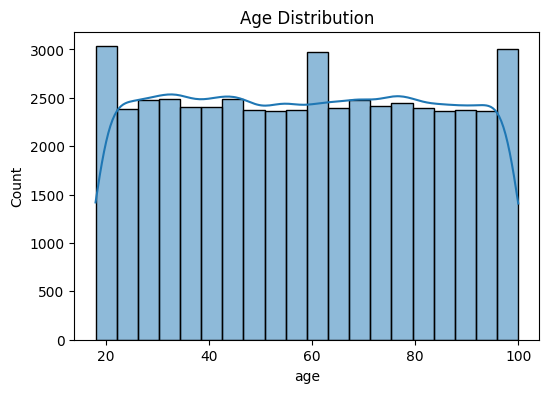

In [12]:
plt.figure(figsize=(6,4))
sns.histplot(df['age'], kde=True, bins=20)
plt.title("Age Distribution")
plt.show()

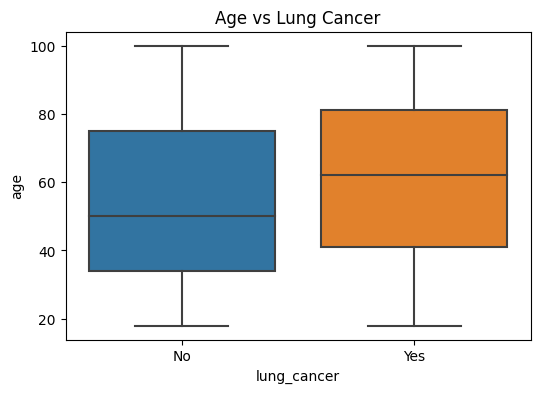

In [13]:
plt.figure(figsize=(6,4))
sns.boxplot(x="lung_cancer", y="age", data=df)
plt.title("Age vs Lung Cancer")
plt.show()

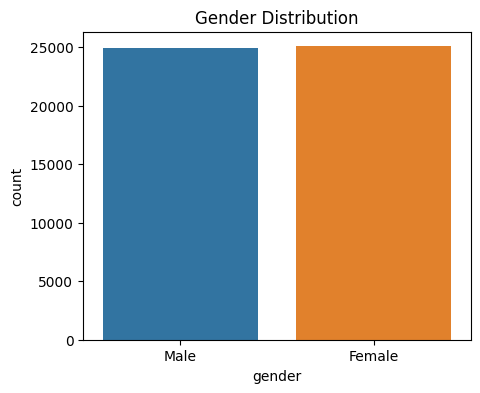

In [14]:
plt.figure(figsize=(5,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()


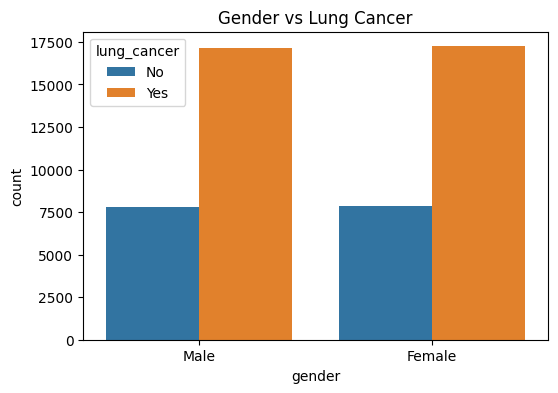

In [15]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", hue="lung_cancer", data=df)
plt.title("Gender vs Lung Cancer")
plt.show()

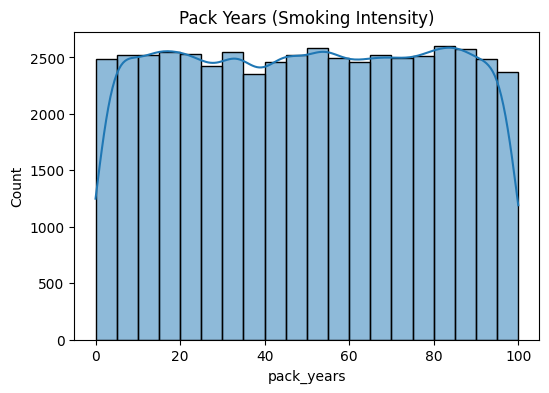

In [16]:
plt.figure(figsize=(6,4))
sns.histplot(df['pack_years'], kde=True, bins=20)
plt.title("Pack Years (Smoking Intensity)")
plt.show()

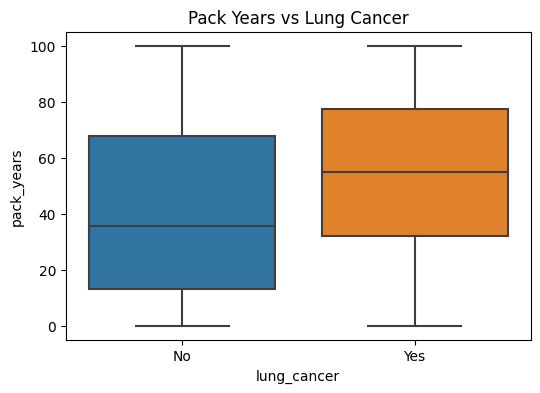

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x="lung_cancer", y="pack_years", data=df)
plt.title("Pack Years vs Lung Cancer")
plt.show()

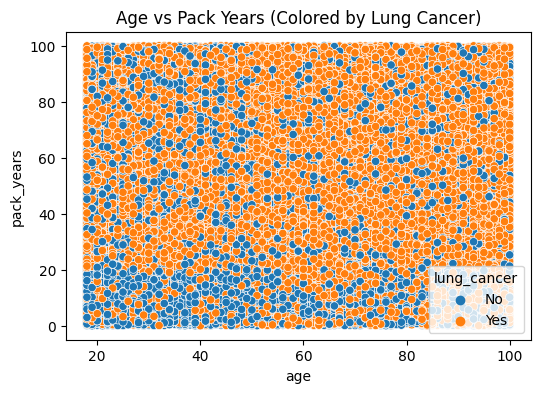

In [18]:
plt.figure(figsize=(6,4))
sns.scatterplot(x="age", y="pack_years", hue="lung_cancer", data=df)
plt.title("Age vs Pack Years (Colored by Lung Cancer)")
plt.show()

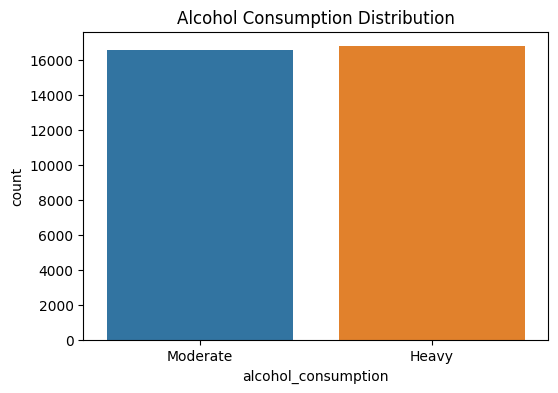

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(x="alcohol_consumption", data=df)
plt.title("Alcohol Consumption Distribution")
plt.show()

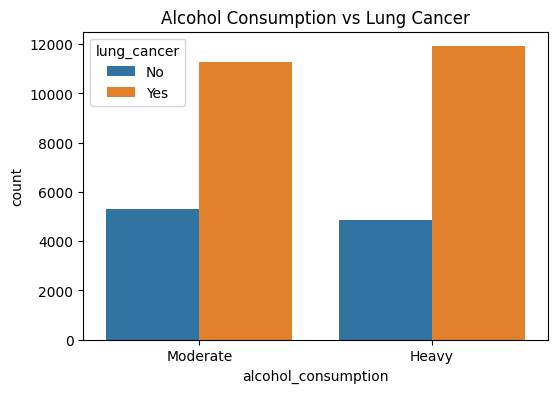

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x="alcohol_consumption", hue="lung_cancer", data=df)
plt.title("Alcohol Consumption vs Lung Cancer")
plt.show()

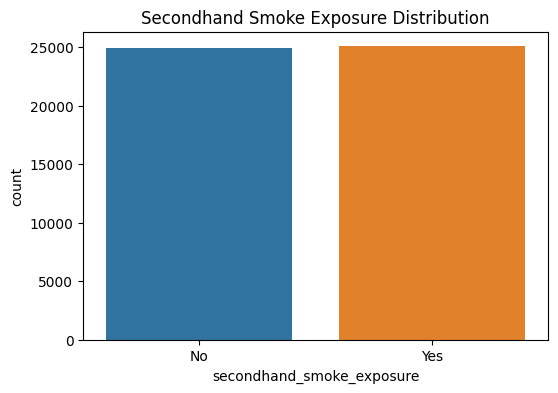

In [21]:
plt.figure(figsize=(6,4))
sns.countplot(x="secondhand_smoke_exposure", data=df)
plt.title("Secondhand Smoke Exposure Distribution")
plt.show()

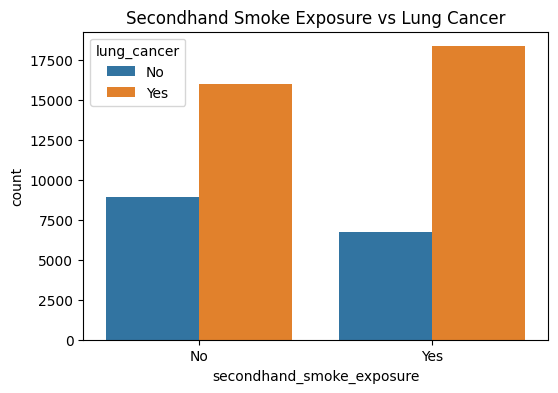

In [22]:
plt.figure(figsize=(6,4))
sns.countplot(x="secondhand_smoke_exposure", hue="lung_cancer", data=df)
plt.title("Secondhand Smoke Exposure vs Lung Cancer")
plt.show()

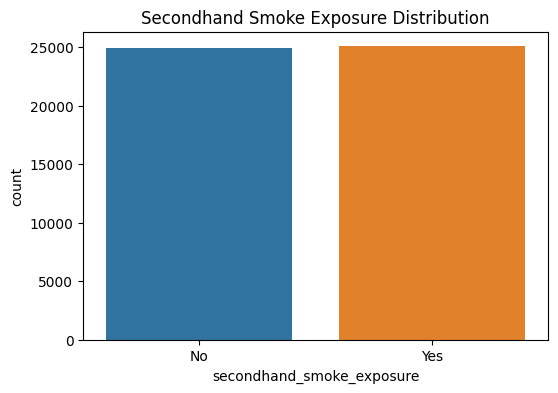

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="secondhand_smoke_exposure", data=df)
plt.title("Secondhand Smoke Exposure Distribution")
plt.show()

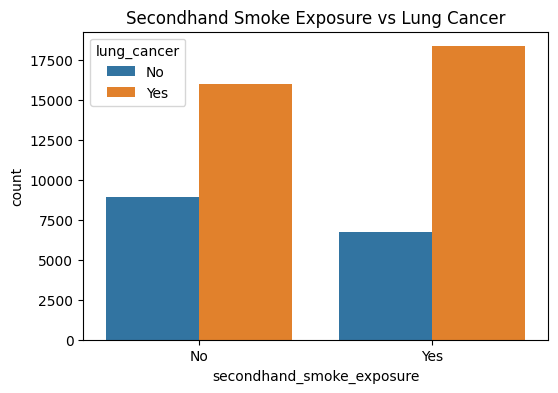

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="secondhand_smoke_exposure", hue="lung_cancer", data=df)
plt.title("Secondhand Smoke Exposure vs Lung Cancer")
plt.show()

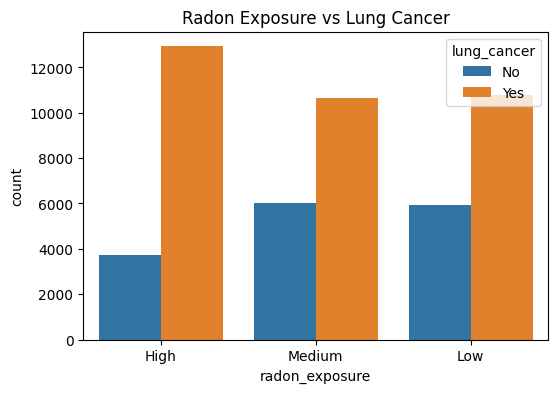

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="radon_exposure", hue="lung_cancer", data=df)
plt.title("Radon Exposure vs Lung Cancer")
plt.show()

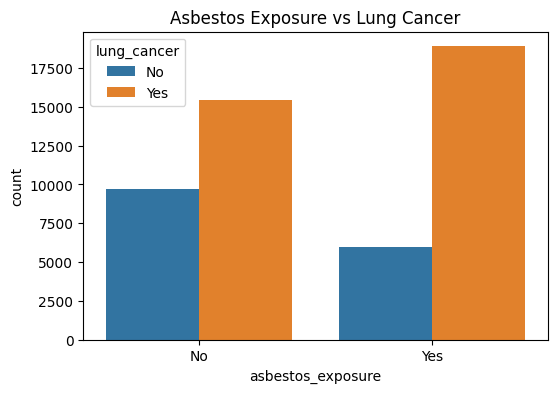

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="asbestos_exposure", hue="lung_cancer", data=df)
plt.title("Asbestos Exposure vs Lung Cancer")
plt.show()

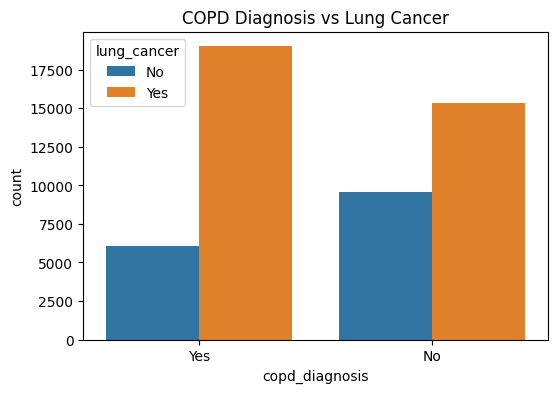

In [27]:
plt.figure(figsize=(6,4))
sns.countplot(x="copd_diagnosis", hue="lung_cancer", data=df)
plt.title("COPD Diagnosis vs Lung Cancer")
plt.show()

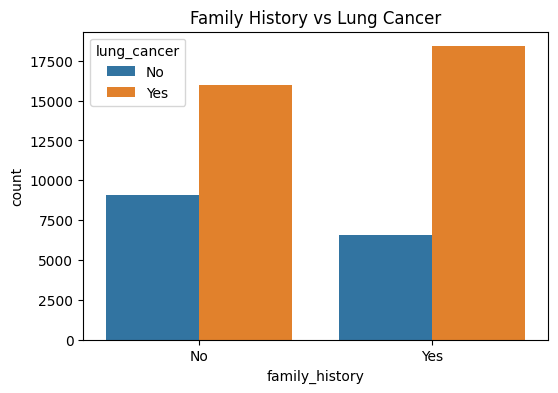

In [28]:

plt.figure(figsize=(6,4))
sns.countplot(x="family_history", hue="lung_cancer", data=df)
plt.title("Family History vs Lung Cancer")
plt.show()

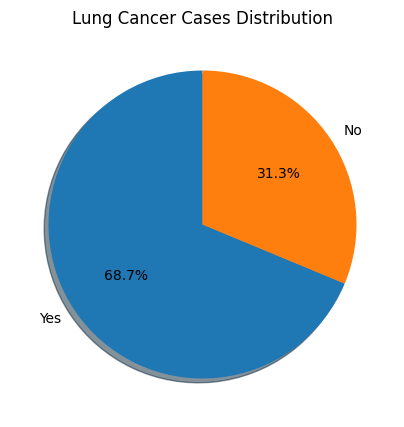

In [29]:
plt.figure(figsize=(5,5))
df['lung_cancer'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, shadow=True)
plt.title("Lung Cancer Cases Distribution")
plt.ylabel("")
plt.show()


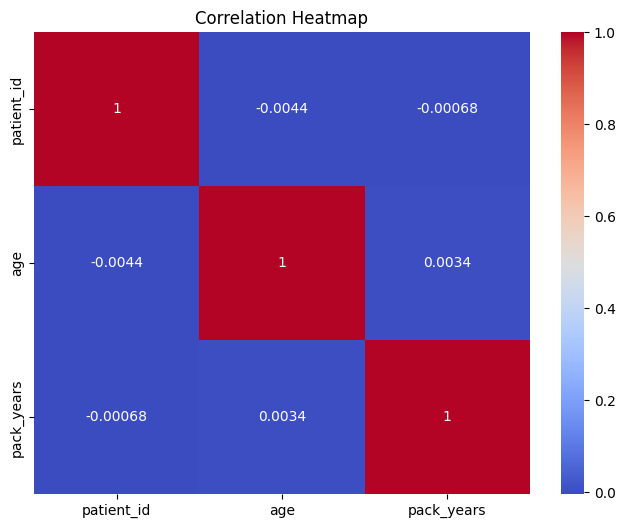

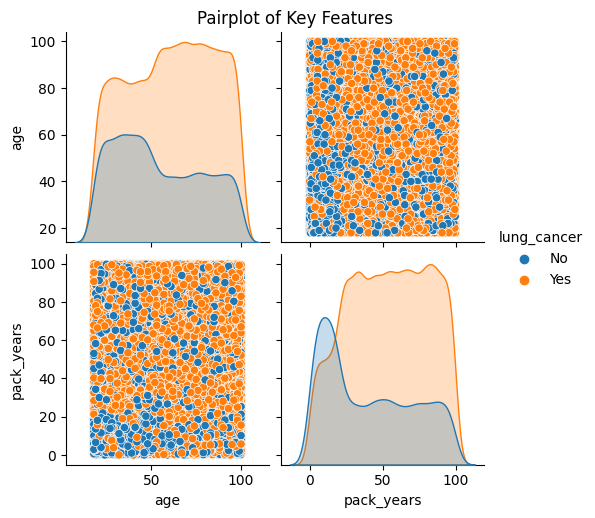

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

sns.pairplot(df[["age", "pack_years", "radon_exposure", "asbestos_exposure", "lung_cancer"]],
             hue="lung_cancer", diag_kind="kde")
plt.suptitle("Pairplot of Key Features", y=1.02)
plt.show()

## Predictve modeling

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [32]:
le = LabelEncoder()
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])


In [33]:
X = df.drop(columns=['patient_id', 'lung_cancer'])
y = df['lung_cancer']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [34]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC()
}

results = {}

In [35]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results[name] = acc
    print(f"{name:20} : {acc:.2f} %")

Logistic Regression  : 72.37 %
Decision Tree        : 65.14 %
Random Forest        : 70.25 %
Gradient Boosting    : 74.40 %
KNN                  : 69.45 %
SVM                  : 73.35 %


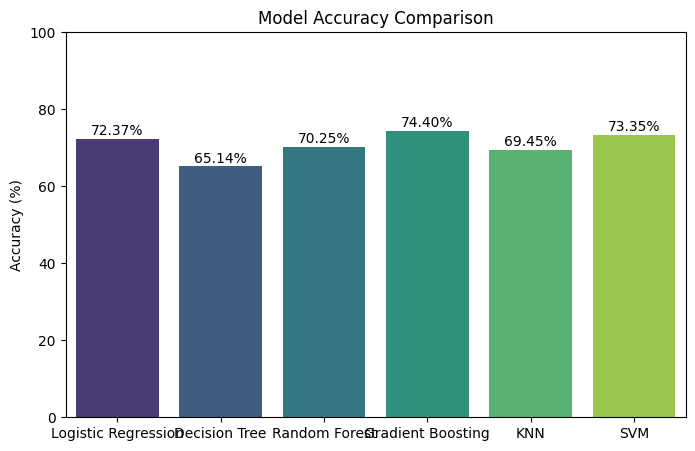

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.title("Model Accuracy Comparison")
for i, v in enumerate(results.values()):
    plt.text(i, v + 1, f"{v:.2f}%", ha='center', fontsize=10)
plt.show()

## Thank you...pls upvote!!!!